# Sanity-Check: Vergleich Original (BIDS) vs. Pipeline Outputs (00, 01)
#
# Dieses Notebook lädt das Original (BIDS) und die von Step 00 / Step 01
# erzeugten .fif-Dateien und zeigt kanalspezifische Vergleiche (PSD, Sensor-Layout,
# kleine Signal-Ausschnitte). Passe `subject` und `person` oben an.


In [1]:
import matplotlib.pyplot as plt
from mne_bids import BIDSPath, read_raw_bids
import mne
from pathlib import Path
import importlib.util

# Anpassen: Subject und Person
subject = '01'   # z.B. '01'
person = 'P1'    # 'P1' oder 'P2'

# Robustes Laden von eeg_pipeline/config.py (funktioniert unabhängig vom Python-Package-Setup)
proj_root = Path.cwd()
config_path = proj_root / 'eeg_pipeline' / 'config.py'
if not config_path.exists():
    # Falls Notebook in a subfolder geöffnet wurde, versuche Workspace-Root
    config_path = proj_root.parent / 'eeg_pipeline' / 'config.py'

spec = importlib.util.spec_from_file_location('pipeline_config', str(config_path))
config = importlib.util.module_from_spec(spec)
spec.loader.exec_module(config)


In [2]:
# Lade Original (BIDS) und Pipeline-Ausgaben (Step 00/01)
from mne_bids import BIDSPath, read_raw_bids
from pathlib import Path

bids_path = BIDSPath(subject=subject, task="RPS", datatype='eeg', suffix='eeg', root=config.BIDS_ROOT)

raw_orig = read_raw_bids(bids_path, verbose=False)
print('Original (BIDS) geladen.')

after00_path = Path(config.OUTPUT_DIR) / f"sub-{subject}_{person}_raw.fif"
after01_path = Path(config.OUTPUT_DIR) / f"sub-{subject}_{person}_renamed_raw.fif"

raw_00 = mne.io.read_raw_fif(str(after00_path), preload=False)
print(f'Step 00 output geladen: {after00_path}')

raw_01 = mne.io.read_raw_fif(str(after01_path), preload=False)
print(f'Step 01 output geladen: {after01_path}')


Original (BIDS) geladen.
Opening raw data file c:\Users\bk57s\Visual Studio Code\EEG_Bala Sharks\data\sub-01_P1_raw.fif...


C:\Users\bk57s\AppData\Local\Temp\ipykernel_31528\4292412381.py:7: RuntimeWarning: Did not find any channels.tsv associated with sub-01_task-RPS.

The search_str was "c:\Users\bk57s\Visual Studio Code\EEG_Bala Sharks\MNE-sample-data\ds006761\sub-01\**\eeg\sub-01*channels.tsv"
  raw_orig = read_raw_bids(bids_path, verbose=False)


Isotrak not found
    Range : 0 ... 7514111 =      0.000 ...  3669.000 secs
Ready.
Step 00 output geladen: c:\Users\bk57s\Visual Studio Code\EEG_Bala Sharks\data\sub-01_P1_raw.fif
Opening raw data file c:\Users\bk57s\Visual Studio Code\EEG_Bala Sharks\data\sub-01_P1_renamed_raw.fif...
    Range : 0 ... 7514111 =      0.000 ...  3669.000 secs
Ready.
Step 01 output geladen: c:\Users\bk57s\Visual Studio Code\EEG_Bala Sharks\data\sub-01_P1_renamed_raw.fif


In [3]:
# Kanal-Zusammenfassung
import mne

def channel_summary(raw):
    if raw is None:
        return {'n_channels': 0, 'eeg': 0, 'eog_names': [], 'ch_names_sample': []}

    n_channels = len(raw.ch_names)
    eeg_idx = mne.pick_types(raw.info, eeg=True)
    eog_idx = mne.pick_types(raw.info, eog=True)
    eog_names = [raw.ch_names[i] for i in eog_idx]

    return {
        'n_channels': n_channels,
        'eeg': len(eeg_idx),
        'eog_names': eog_names,
        'ch_names_sample': raw.ch_names[:20]
    }

print('--- Summaries ---')
print('Original (BIDS):', channel_summary(raw_orig))
print('After 00 (split):', channel_summary(raw_00))
print('After 01 (renamed):', channel_summary(raw_01))


--- Summaries ---
Original (BIDS): {'n_channels': 143, 'eeg': 142, 'eog_names': [], 'ch_names_sample': ['1-A1', '1-A2', '1-A3', '1-A4', '1-A5', '1-A6', '1-A7', '1-A8', '1-A9', '1-A10', '1-A11', '1-A12', '1-A13', '1-A14', '1-A15', '1-A16', '1-A17', '1-A18', '1-A19', '1-A20']}
After 00 (split): {'n_channels': 70, 'eeg': 64, 'eog_names': ['1-Erg1', '1-Erg2'], 'ch_names_sample': ['1-A1', '1-A2', '1-A3', '1-A4', '1-A5', '1-A6', '1-A7', '1-A8', '1-A9', '1-A10', '1-A11', '1-A12', '1-A13', '1-A14', '1-A15', '1-A16', '1-A17', '1-A18', '1-A19', '1-A20']}
After 01 (renamed): {'n_channels': 70, 'eeg': 64, 'eog_names': ['1-Erg1', '1-Erg2'], 'ch_names_sample': ['Fp1', 'AF7', 'AF3', 'F1', 'F3', 'F5', 'F7', 'FT7', 'FC5', 'FC3', 'FC1', 'C1', 'C3', 'C5', 'T7', 'TP7', 'CP5', 'CP3', 'CP1', 'P1']}


NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 1.000 (s)


C:\Users\bk57s\AppData\Local\Temp\ipykernel_31528\2551707673.py:6: UserWarning: Zero value in spectrum for channels 1-GSR1, 1-GSR2, 1-Resp, 1-Plet, 1-Temp, 2-GSR1, 2-GSR2, 2-Resp, 2-Plet, 2-Temp
  raw_orig.plot_psd(fmin=1, fmax=40, ax=axes[0], show=False)


Plotting power spectral density (dB=True).


C:\Users\bk57s\AppData\Local\Temp\ipykernel_31528\2551707673.py:6: UserWarning: Infinite value in PSD for channels 1-GSR1, 1-GSR2, 1-Resp, 1-Plet, 1-Temp, 2-GSR1, 2-GSR2, 2-Resp, 2-Plet, 2-Temp.
These channels might be dead.
  raw_orig.plot_psd(fmin=1, fmax=40, ax=axes[0], show=False)
C:\Users\bk57s\AppData\Local\Temp\ipykernel_31528\2551707673.py:6: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw_orig.plot_psd(fmin=1, fmax=40, ax=axes[0], show=False)


NOTE: plot_psd() is a legacy function. New code should use .compute_psd().plot().
Effective window size : 1.000 (s)
Plotting power spectral density (dB=True).


C:\Users\bk57s\AppData\Local\Temp\ipykernel_31528\2551707673.py:12: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


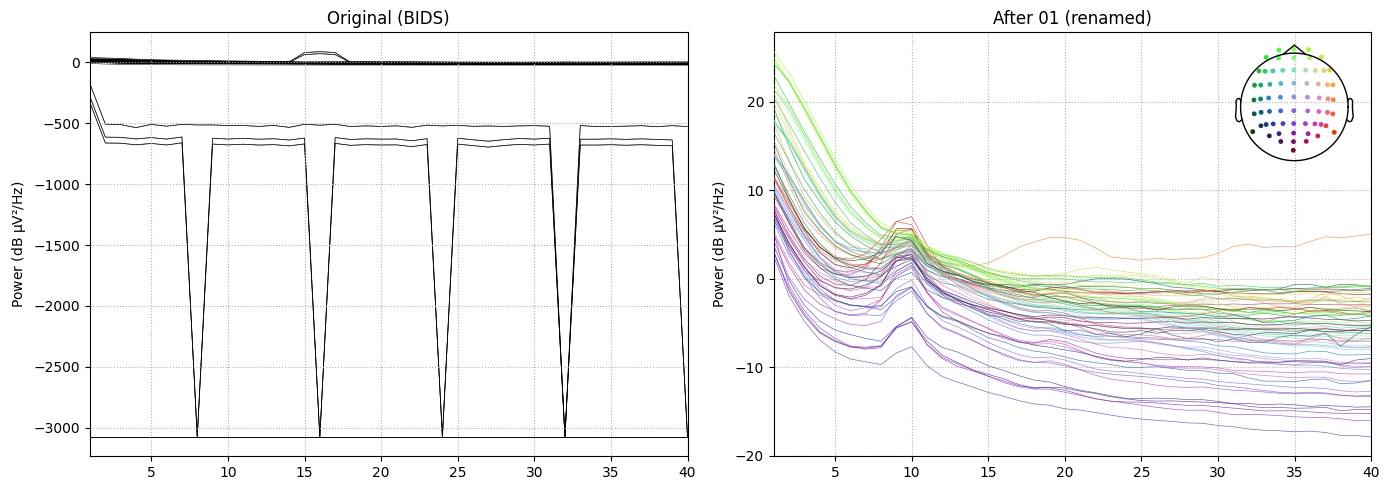

In [4]:
# PSD-Vergleich: Original vs After01
import matplotlib.pyplot as plt

if raw_orig is not None and raw_01 is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    raw_orig.plot_psd(fmin=1, fmax=40, ax=axes[0], show=False)
    axes[0].set_title('Original (BIDS)')

    raw_01.plot_psd(fmin=1, fmax=40, ax=axes[1], show=False)
    axes[1].set_title('After 01 (renamed)')

    plt.tight_layout()
    plt.show()
else:
    print('PSD-Vergleich übersprungen (fehlende Dateien).')


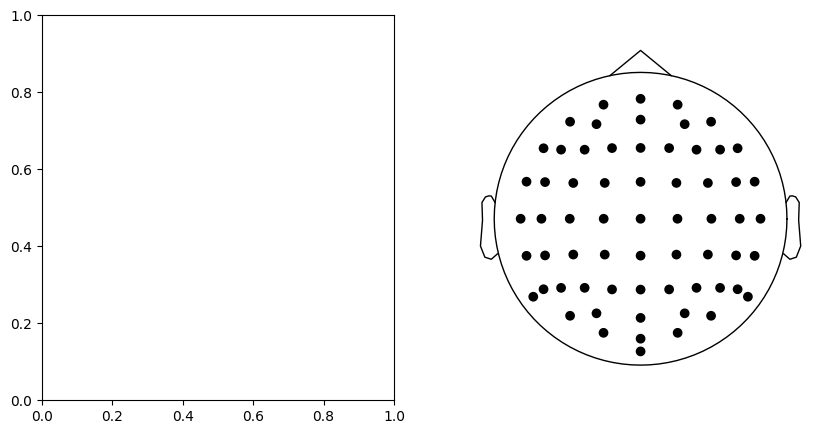

<Figure size 640x480 with 0 Axes>

In [7]:
# Sensor-Layout Vergleich
import matplotlib.pyplot as plt

if raw_orig is not None and raw_01 is not None:
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    #mne.viz.plot_sensors(raw_orig.info, axes=axes[0], show_names=False, title='Original')
    mne.viz.plot_sensors(raw_01.info, axes=axes[1], show_names=False, title='After 01')
    plt.tight_layout()
    plt.show()
else:
    print('Sensor-Layout Vergleich übersprungen (fehlende Dateien).')


In [8]:
# Zeitreihen-Vergleich (erste 5 s) für bis zu 6 gemeinsamen EEG-Kanäle
import numpy as np

if raw_orig is not None and raw_01 is not None:
    ch_src = raw_orig.copy().pick_types(eeg=True).ch_names if raw_orig is not None else []
    ch_ren = raw_01.copy().pick_types(eeg=True).ch_names if raw_01 is not None else []
    common = [c for c in ch_src if c in ch_ren][:6]
    if not common:
        print('Keine gemeinsamen EEG-Kanäle zum Vergleichen gefunden.')
    else:
        sfreq = raw_orig.info['sfreq']
        t_max = min(5.0, raw_orig.times[-1])
        n_samples = int(sfreq * t_max)
        fig, axes = plt.subplots(len(common), 1, figsize=(12, 2*len(common)), sharex=True)
        if len(common) == 1:
            axes = [axes]
        for i, ch in enumerate(common):
            sig_o = raw_orig.copy().pick_channels([ch]).get_data()[0, :n_samples]
            sig_1 = raw_01.copy().pick_channels([ch]).get_data()[0, :n_samples]
            axes[i].plot(np.arange(n_samples)/sfreq, sig_o * 1e6, label='orig (µV)', alpha=0.8)
            axes[i].plot(np.arange(n_samples)/sfreq, sig_1 * 1e6, label='after01 (µV)', alpha=0.7)
            axes[i].set_ylabel(ch)
            if i == 0:
                axes[i].legend(loc='upper right')
        axes[-1].set_xlabel('Time (s)')
        plt.tight_layout()
        plt.show()
else:
    print('Zeitreihen-Vergleich übersprungen (fehlende Dateien).')


NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
NOTE: pick_types() is a legacy function. New code should use inst.pick(...).
Keine gemeinsamen EEG-Kanäle zum Vergleichen gefunden.


## Run- und Regenerierungs-Anweisungen

Wenn die Step-00 / Step-01 Dateien fehlen, kannst du die Pipeline-Schritte von der Projekt-Root aus starten:

```bash
python eeg_pipeline/00_load_data_per_person.py
python eeg_pipeline/01_inspect_and_rename.py
```

Passe vor dem Ausführen `subject` und `person` in der zweiten Zelle des Notebooks an.
